# This Notebook gives a short example of a policy simulation 

It can be executed in the cloud with Google colab
## Run the notebook

To start, select:

**Google Colab:** Runtime → Run all  

The notebook may take a little time to finish starting.


To open  in colab press the button: 

<a href="https://colab.research.google.com/github/IbHansen/mfdemo/blob/main/Pakistan/PAK_CarbonTax.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%matplotlib Notebook

In [2]:
#This is code to manage dependencies if the notebook is executed in the google colab cloud service
# Only run installs on Colab
import importlib.util

if 'google.colab' in str(get_ipython()):
    if importlib.util.find_spec("modelclass") is None:
        !apt-get -qq install -y graphviz
        !pip -qq install ModelFlowIb > /dev/null 2>&1
        !mkdir -p data && curl -L https://raw.githubusercontent.com/worldbank/MFMod-ModelFlow/main/models/Pakistan/data/pak_new.pcim -o data/pak_new.pcim

In [3]:
from modelclass import model

## Run Pakistan baseline

In [4]:
mpak,bline = model.modelload('data/pak_new.pcim',run=True)

Zipped file read:  data\pak_new.pcim


## Simulating the impact of imposing a carbon price

To run a simulation, the following steps must invariably be followed.
1. Create a new DataFrame, typically a copy of an existing one.
2. Change the value in the new df of the variable(s) to be shocked.
3. Solve the model using the newly altered df as the input df.

## Simulating the impact of imposing a carbon price

A simulation follows three steps:

1. **Create a scenario DataFrame** from a baseline using `.upd()`, which applies an update expression that sets, scales, or grows selected variables over a chosen time range.
2. **Solve the model** by calling it with the scenario DataFrame, a start and end year, and a `keep=` label that names the scenario for later comparison.
3. **Inspect results** on the returned DataFrame or directly on the model, which stores each kept scenario.

### Create a scenario DataFrame*

Using the `.upd()` expression syntax

```
<start end>  VAR1 VAR2 ...  <op>  value
```

- **Time range** `<start end>` is optional; omit it to cover the full index.
- **Variables** are space-separated; wildcards (`*`, `?`) are supported.
- **Operators**: `=` (set), `+` (add), `*` (multiply), `%` (percent change),
  `=growth` / `+growth` (growth rate), `=diff` (difference).
  
Stacking more lines in the update string lets you shock several variables or time
ranges in one call.

## Example — a $30 nominal carbon tax on coal, gas, and oil, 2025–2050

In [ ]:
CT30df = bline.upd("<2025 2050> PAKGGREVCO2CER PAKGGREVCO2GER PAKGGREVCO2OER = 30")

### Solve the model

In [5]:
resultsdf = mpak(CT30df,2020,2050,keep="Nominal $30USD Carbon tax") # simulates the model

### Inspect results

In [18]:
mpak['PAKCCEMISCO2*'].difpctlevel.df.T.style.format("{:.2f}")

,2020,2021,2022,2023,2024,2025,2026,2027,2028,2029,2030,2031,2032,2033,2034,2035,2036,2037,2038,2039,2040,2041,2042,2043,2044,2045,2046,2047,2048,2049,2050
PAKCCEMISCO2CKN,0.00,0.00,0.00,0.00,0.00,-41.19,-40.06,-38.85,-37.59,-36.26,-34.89,-33.50,-32.11,-30.72,-29.36,-28.02,-26.73,-25.47,-24.25,-23.07,-21.94,-20.85,-19.81,-18.81,-17.85,-16.93,-16.06,-15.22,-14.42,-13.66,-12.92
PAKCCEMISCO2GKN,0.00,0.00,0.00,0.00,0.00,-26.99,-25.72,-24.48,-23.30,-22.14,-21.01,-19.89,-18.80,-17.74,-16.71,-15.73,-14.79,-13.90,-13.05,-12.26,-11.50,-10.80,-10.14,-9.52,-8.94,-8.40,-7.89,-7.41,-6.97,-6.55,-6.15
PAKCCEMISCO2OKN,0.00,0.00,0.00,0.00,0.00,-10.93,-10.98,-10.89,-10.68,-10.35,-9.95,-9.48,-8.99,-8.48,-7.98,-7.50,-7.03,-6.58,-6.15,-5.75,-5.38,-5.02,-4.70,-4.39,-4.10,-3.84,-3.58,-3.35,-3.13,-2.92,-2.73
PAKCCEMISCO2TKN,0.00,0.00,0.00,0.00,0.00,-22.17,-21.56,-20.89,-20.17,-19.38,-18.55,-17.69,-16.82,-15.96,-15.12,-14.30,-13.52,-12.76,-12.04,-11.36,-10.71,-10.10,-9.52,-8.97,-8.45,-7.96,-7.50,-7.07,-6.66,-6.27,-5.90


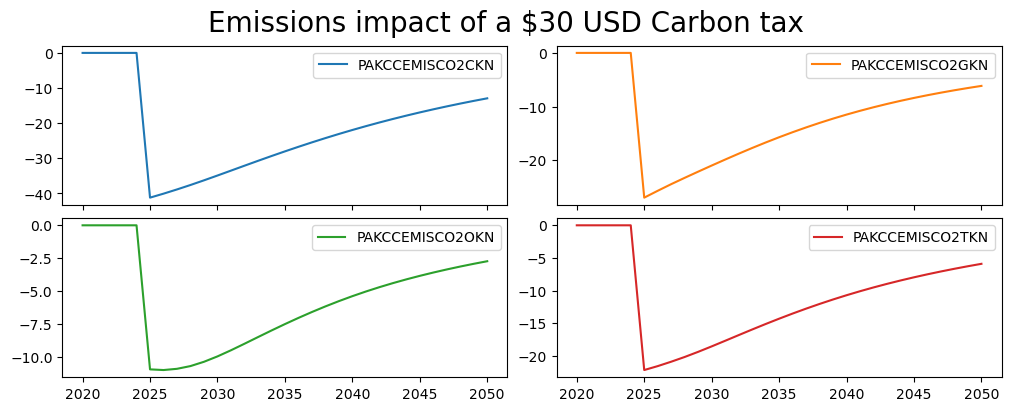

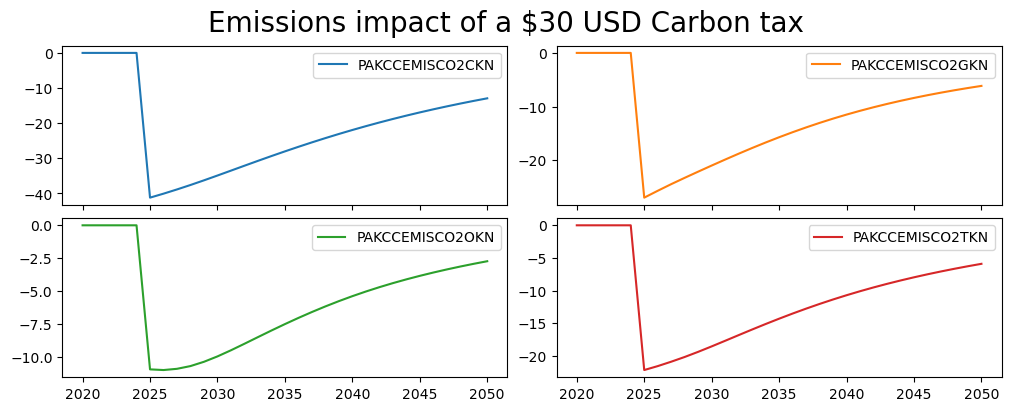

In [7]:
mpak['PAKCCEMISCO2?KN'].difpctlevel.rename().plot(title="Emissions impact of a $30 USD Carbon tax")

In [8]:
mpak['PAKFMLBLPOLYXN']